# 03 — Video Statistics

Deep dive into video and media technical properties.

**Analyzer:** `VideoAnalyzer`  
**Outputs:** `video_statistics_report.md`, `summary.json`, `video_stats_summary.csv`, `resolution_distribution.csv`

## Setup

In [1]:
import sys, time
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_NAME = "03_video_statistics"
START_TIME = time.time()

from eda.utils.config import load_config
from eda.utils.logger import EDALogger
from eda.utils.metadata_loader import MetadataLoader
from eda.utils.wandb_manager import WandbManager
from eda.utils.plotting import PlotEngine, CATEGORICAL_COLOURS, DATASET_COLOURS
from eda.utils.report_generator import ReportGenerator
from eda.utils.system_monitor import SystemMonitor
from eda.utils.output_manager import OutputManager
from eda.utils.statistics import VideoAnalyzer
import pandas as pd
import matplotlib.pyplot as plt

config = load_config()
logger = EDALogger.setup(config, NOTEBOOK_NAME)
monitor = SystemMonitor()
plot_engine = PlotEngine(dpi=config.figure_dpi, formats=config.figure_formats)
output = OutputManager(config, NOTEBOOK_NAME)
snap_start = monitor.snapshot("start")
logger.log_start()

[22:12:14] INFO     ═══ EDA START: 03_video_statistics ═══ | EDA v1.0.0 | Python 3.13.2 | Windows


In [2]:
loader = MetadataLoader(config)
df = loader.load()
metadata_hash = loader.metadata_hash
git_commit = EDALogger.get_git_commit()

wb = WandbManager(config, NOTEBOOK_NAME)
wb.init(metadata_hash=metadata_hash, git_commit=git_commit)
wb.log_system_info(snap_start)
logger.log_data_loaded(df.shape[0], df.shape[1], metadata_hash)

Preprocessing: Completely empty columns: ['duplicate_group_id']


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Amita nagar\_netrc.


wandb: Currently logged in as: saksham4data (saksham4data-vinkura) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: setting up run ifnajcp0


...

wandb: Run data is saved locally in E:\Rads\eda\notebooks\wandb\run-20260801_221218-ifnajcp0
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run eda-03_video_statistics


wandb:  View project at https://wandb.ai/saksham4data-vinkura/RADS


wandb:  View run at https://wandb.ai/saksham4data-vinkura/RADS/runs/ifnajcp0


[22:12:20] INFO     Data loaded: 5338 rows × 51 columns | hash=sha256:a761cf722...


## Analysis

In [3]:
analyzer = VideoAnalyzer(df, config)
results = analyzer.analyze()

# Duration summary
dur = results["duration"]
if dur.get("available") and dur.get("count", 0) > 0:
    stats = dur["stats"]
    print(f"Duration — {dur['count']:,} records")
    print(f"  Mean: {stats['mean']:.2f}s  |  Median: {stats['median']:.2f}s")
    print(f"  Min:  {stats['min']:.2f}s  |  Max:    {stats['max']:.2f}s")
else:
    print("Duration data not available")

# FPS summary
fps = results["fps"]
if fps.get("available") and fps.get("count", 0) > 0:
    print(f"\nFPS — {fps['count']:,} records")
    print(f"  Common FPS: {fps.get('common_fps', {})}")

# Resolution summary
res = results["resolution"]
if res.get("available") and res.get("count", 0) > 0:
    print(f"\nResolution — {res['count']:,} records")
    print(f"  Common: {dict(list(res.get('common_resolutions', {}).items())[:5])}")

# Image subset
img = results["image_subset"]
if img.get("available") and img.get("count", 0) > 0:
    print(f"\nImage-only subset: {img['count']:,} records")

# Outliers
outliers = results["outliers"]
if outliers:
    print("\n── Outliers (IQR) ──")
    for col, info in outliers.items():
        print(f"  {col}: {info['count']} outliers ({info['percentage']:.1f}%)")

Duration — 4,349 records
  Mean: 19.35s  |  Median: 18.75s
  Min:  0.48s  |  Max:    114.96s

FPS — 4,349 records
  Common FPS: {'20.0': 2279, '15.0': 808, '30.0': 221, '8.0': 117, '25.0': 102, '14.0': 88, '0.0': 67, '13.0': 58, '10.0': 51, '24.0': 47}

Resolution — 5,338 records
  Common: {'1080×1920': 2520, '720×1280': 1590, '720×960': 355, '720×1080': 123, '720×1056': 103}

Image-only subset: 989 records

── Outliers (IQR) ──
  duration: 8 outliers (0.2%)
  fps: 521 outliers (12.0%)
  no_frames: 245 outliers (5.6%)
  file_size_bytes: 413 outliers (7.7%)


## Visualisation

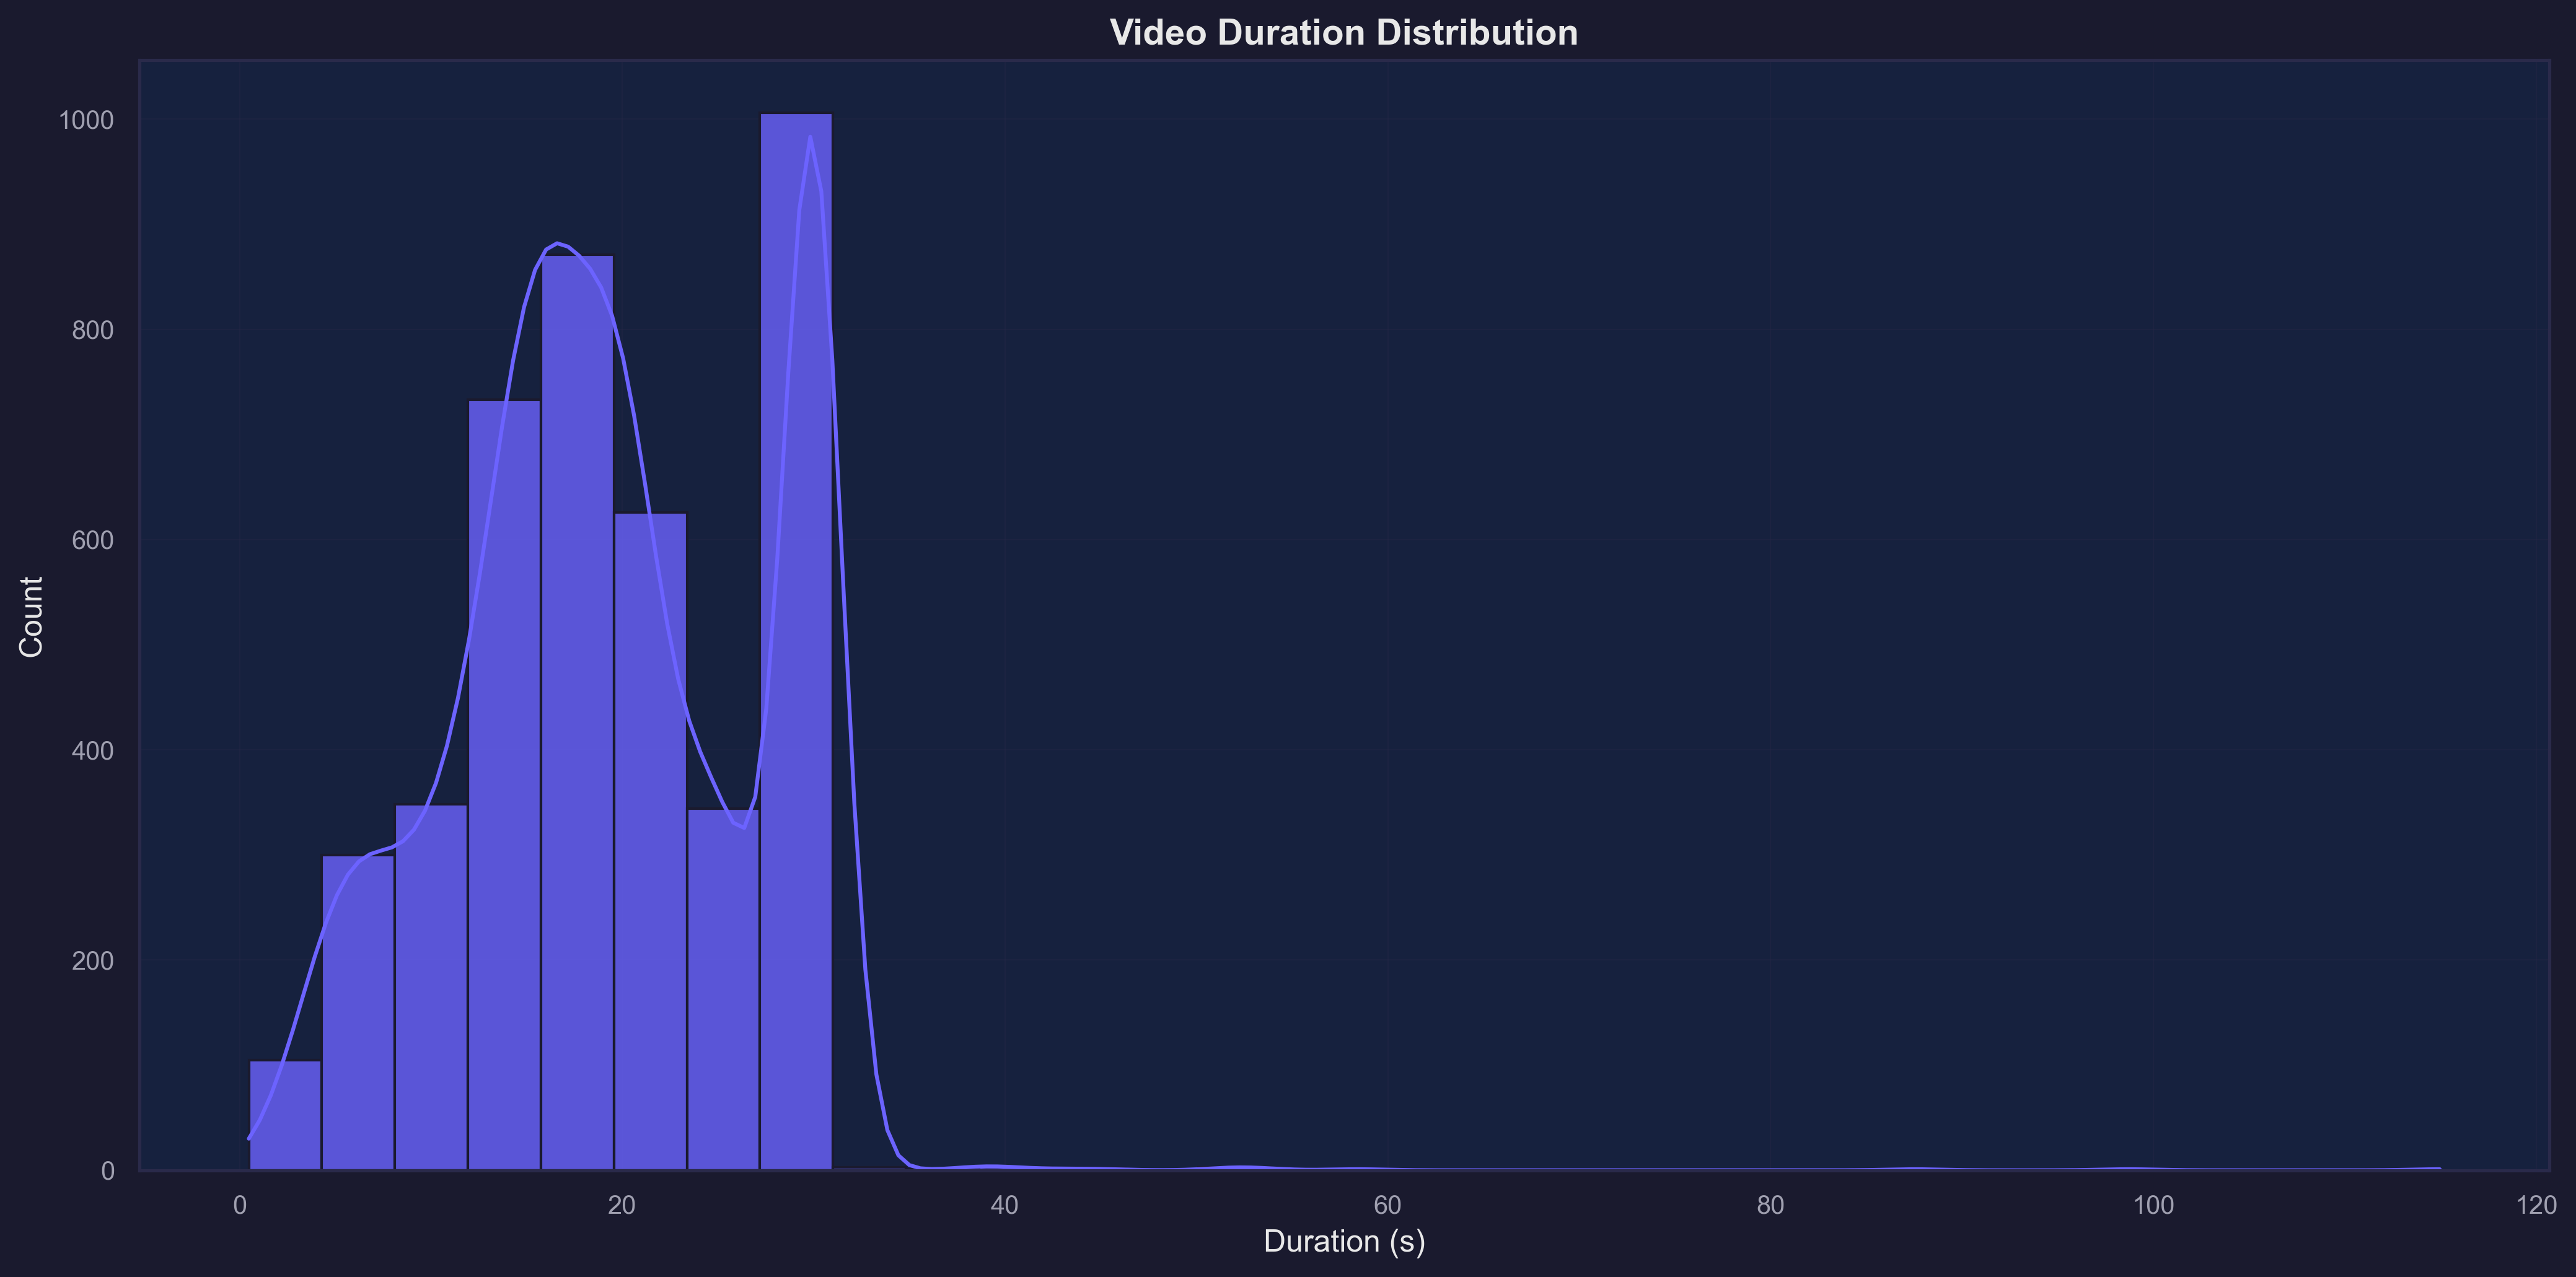

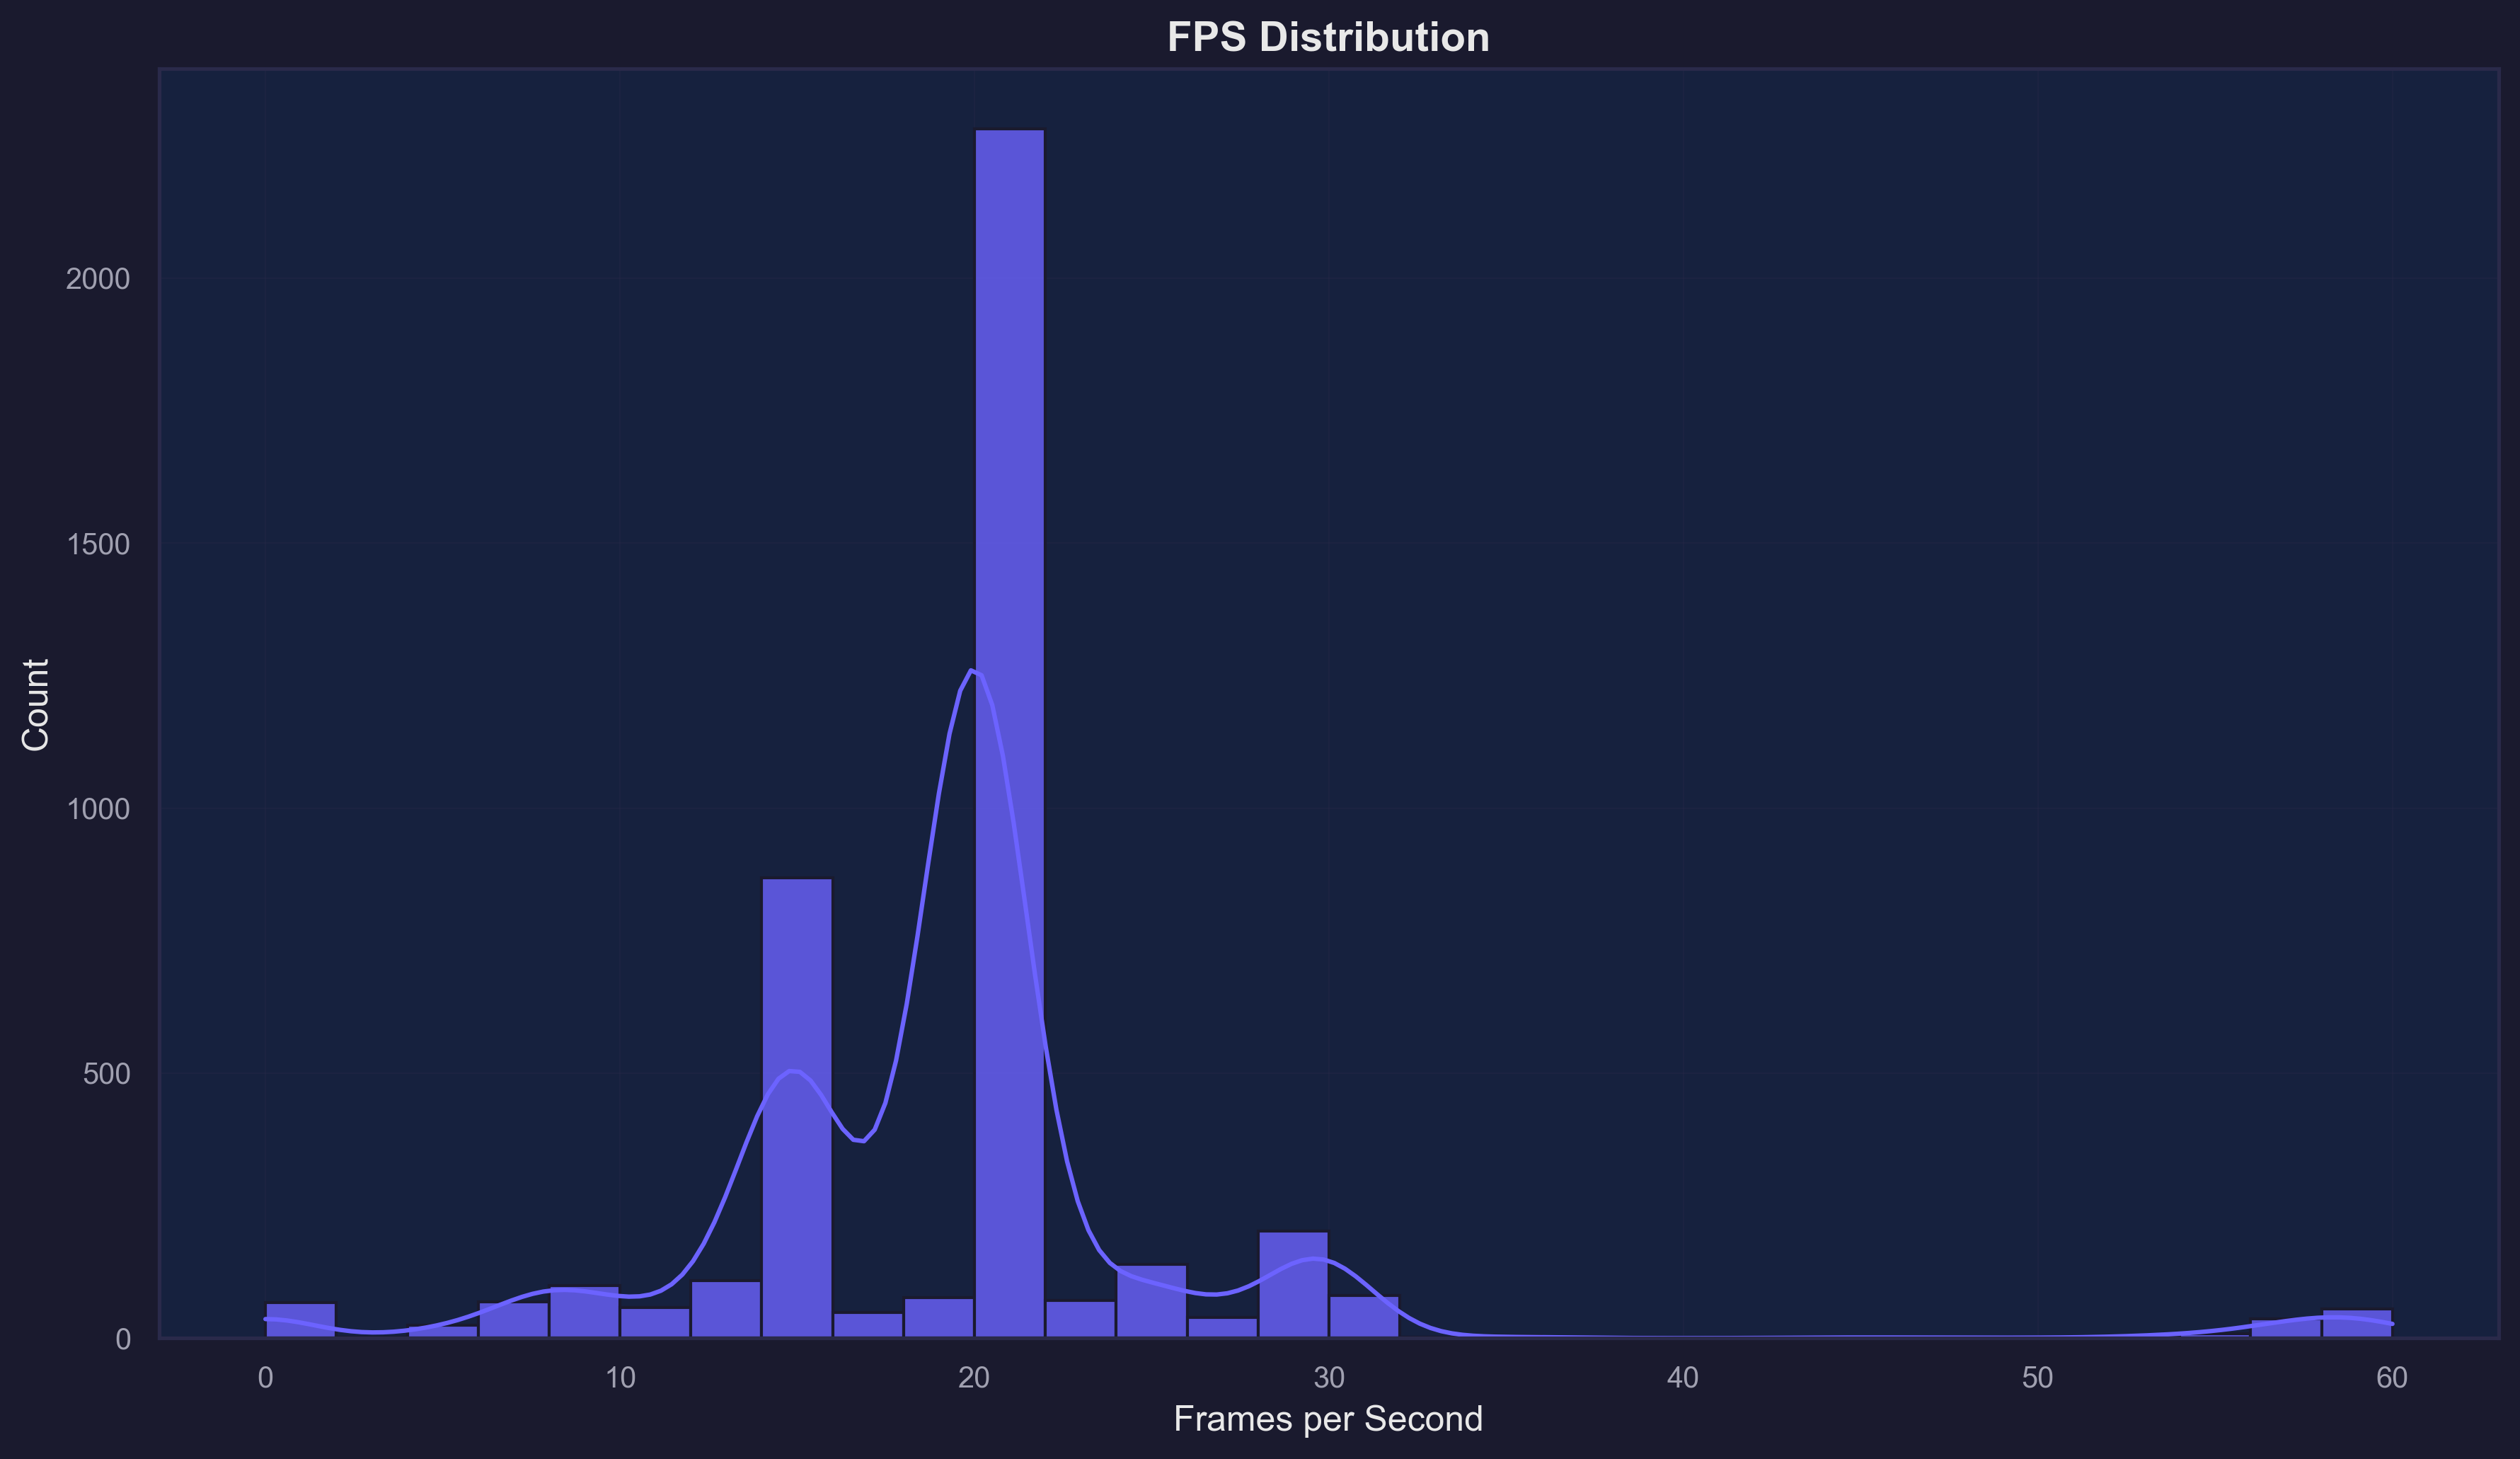

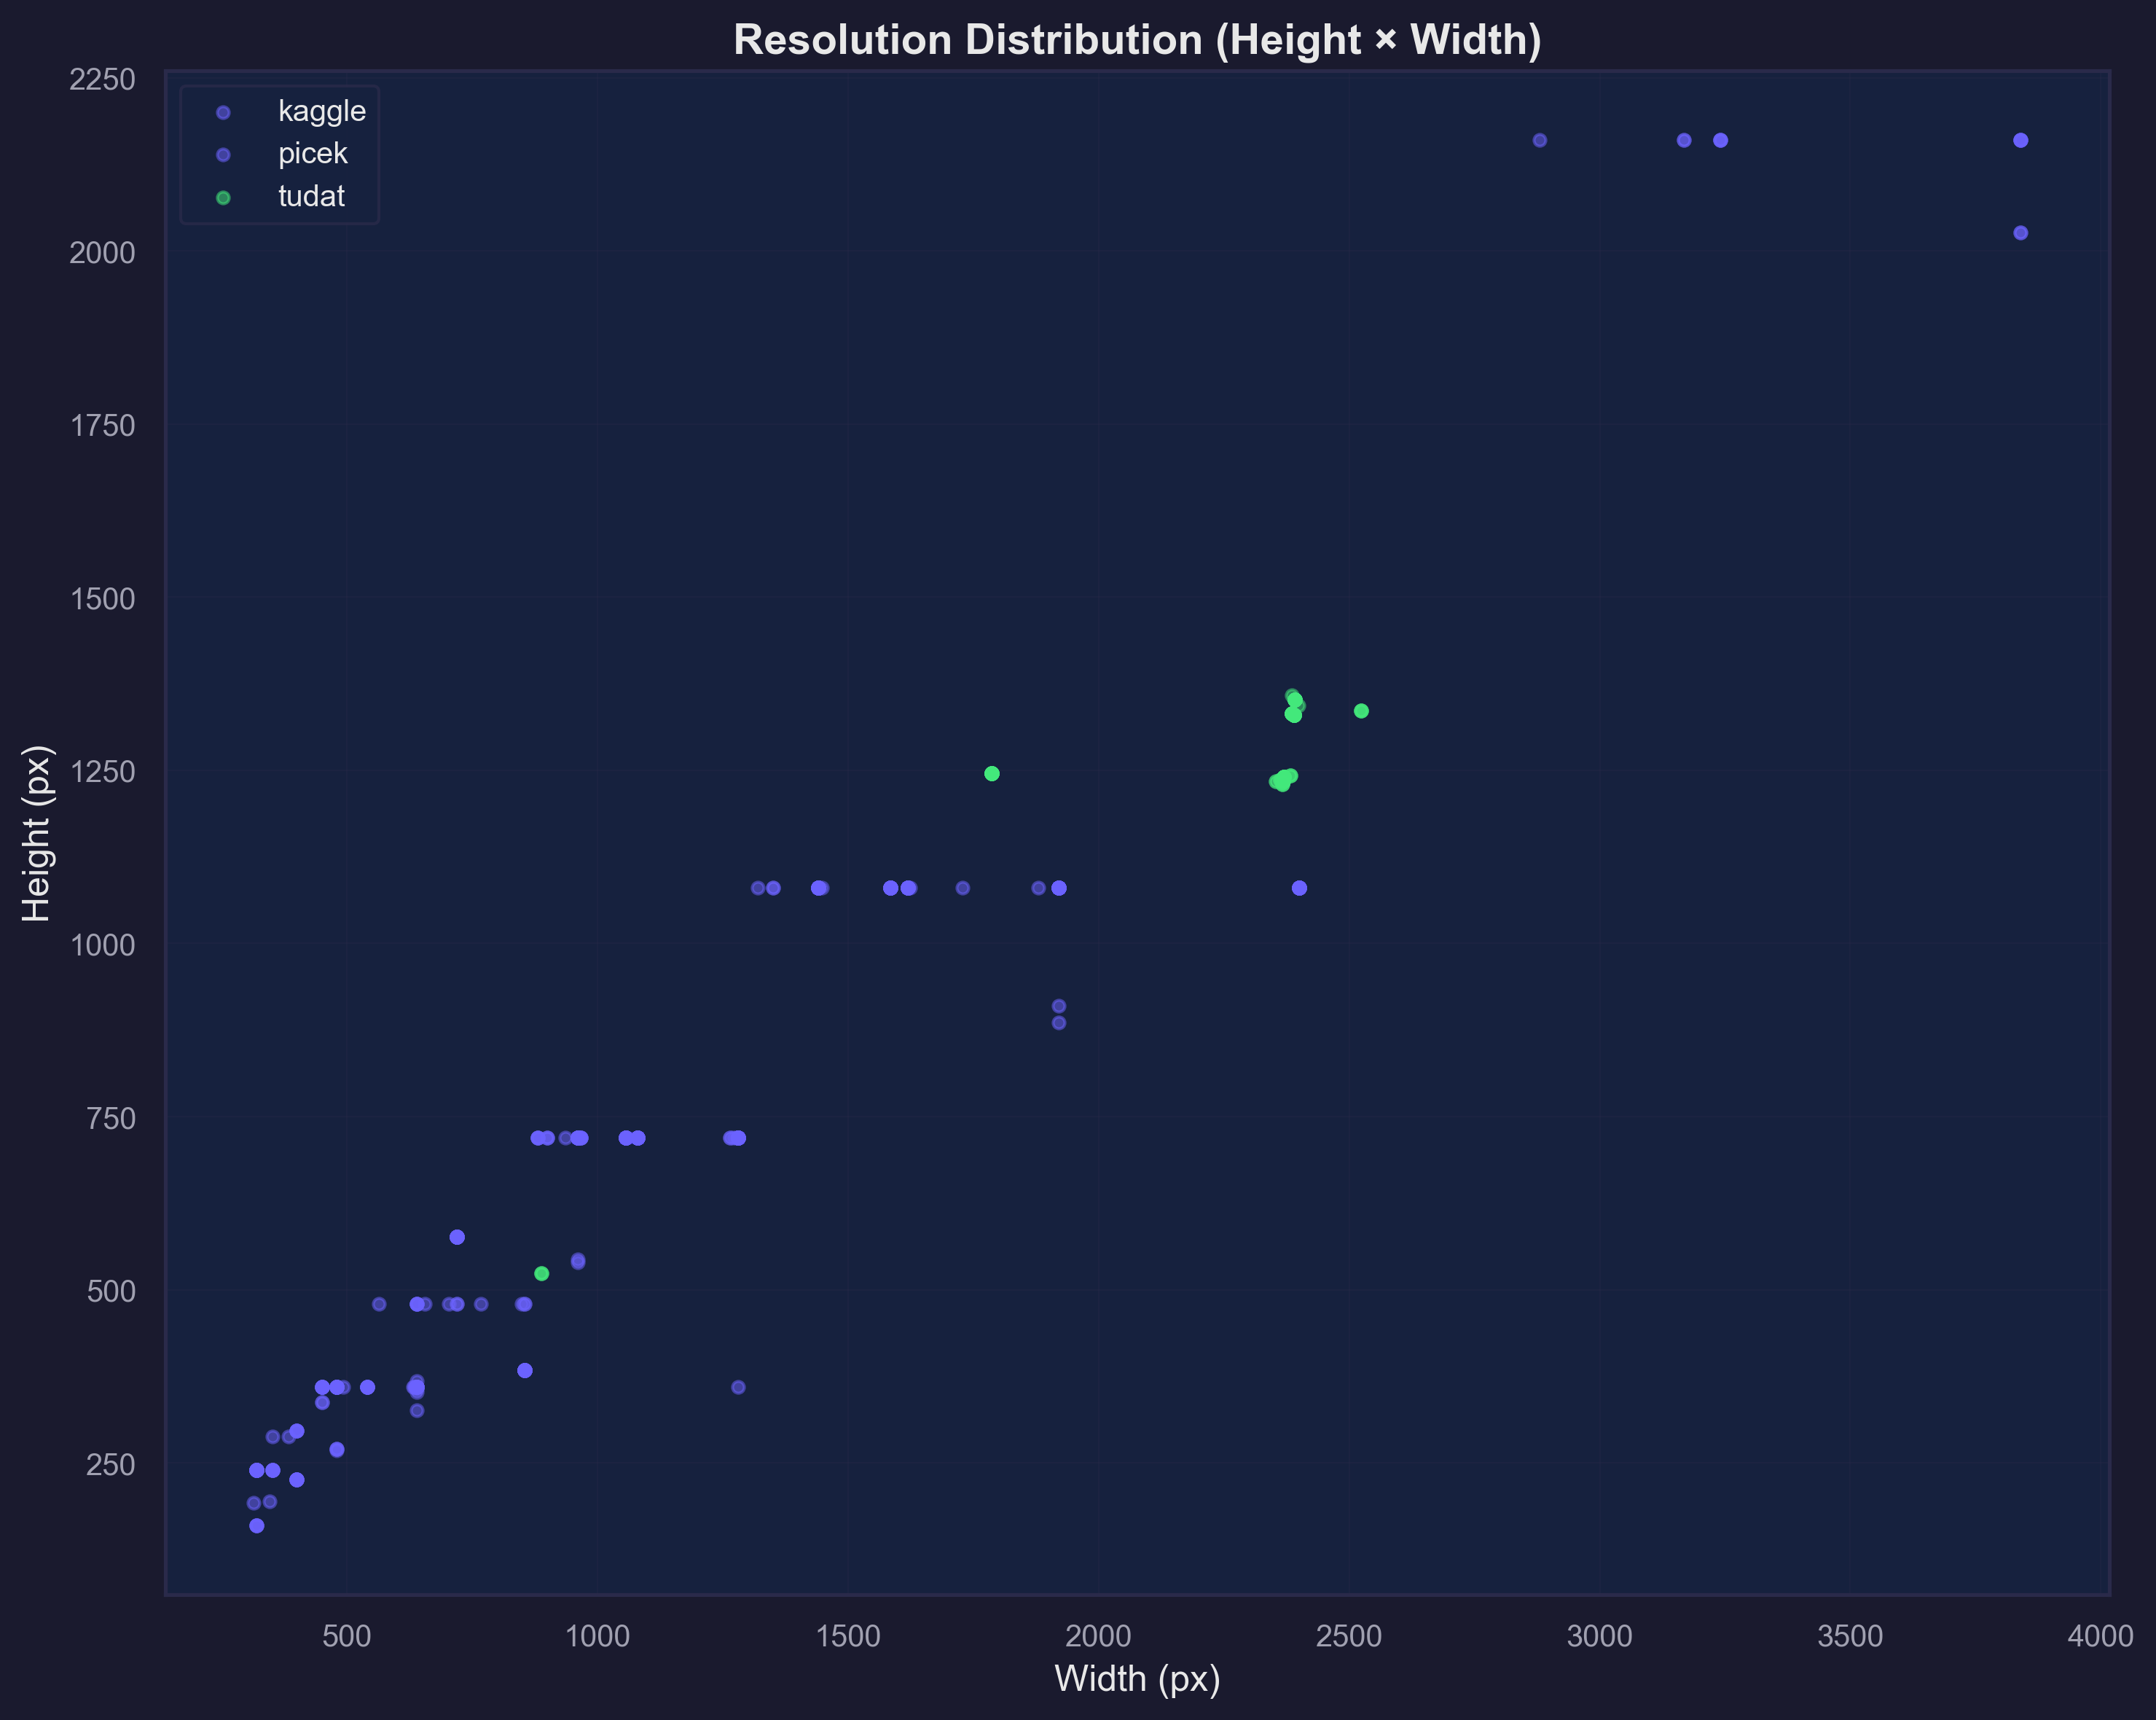

In [4]:
# Duration distribution
if dur.get("available") and dur.get("count", 0) > 0:
    fig, ax = plot_engine.create_figure(figsize=(14, 7))
    plot_engine.plot_distribution(
        df["duration"].dropna(),
        title="Video Duration Distribution",
        xlabel="Duration (s)",
        ax=ax,
    )
    plt.tight_layout()
    output.save_figure(fig, "duration_distribution")
    wb.log_figure(fig, "duration_distribution")
    plt.show()

# FPS distribution
if fps.get("available") and fps.get("count", 0) > 0:
    fig, ax = plot_engine.create_figure(figsize=(12, 7))
    plot_engine.plot_distribution(
        df["fps"].dropna(),
        title="FPS Distribution",
        xlabel="Frames per Second",
        ax=ax,
    )
    plt.tight_layout()
    output.save_figure(fig, "fps_distribution")
    wb.log_figure(fig, "fps_distribution")
    plt.show()

# Resolution scatter (height vs width)
if res.get("available") and res.get("count", 0) > 0:
    fig, ax = plot_engine.create_figure(figsize=(10, 8))
    valid_hw = df[["height", "width"]].dropna()
    # Colour by dataset if available
    if "dataset_name" in df.columns:
        for ds in analyzer.iter_datasets():
            ds_df = df[df["dataset_name"] == ds][["height", "width"]].dropna()
            ax.scatter(
                ds_df["width"], ds_df["height"],
                label=ds, alpha=0.5, s=15,
                color=DATASET_COLOURS.get(ds, "#6C63FF"),
            )
        ax.legend()
    else:
        ax.scatter(valid_hw["width"], valid_hw["height"], alpha=0.5, s=15)
    ax.set_xlabel("Width (px)")
    ax.set_ylabel("Height (px)")
    ax.set_title("Resolution Distribution (Height × Width)", fontweight="bold")
    plt.tight_layout()
    output.save_figure(fig, "resolution_scatter")
    wb.log_figure(fig, "resolution_scatter")
    plt.show()

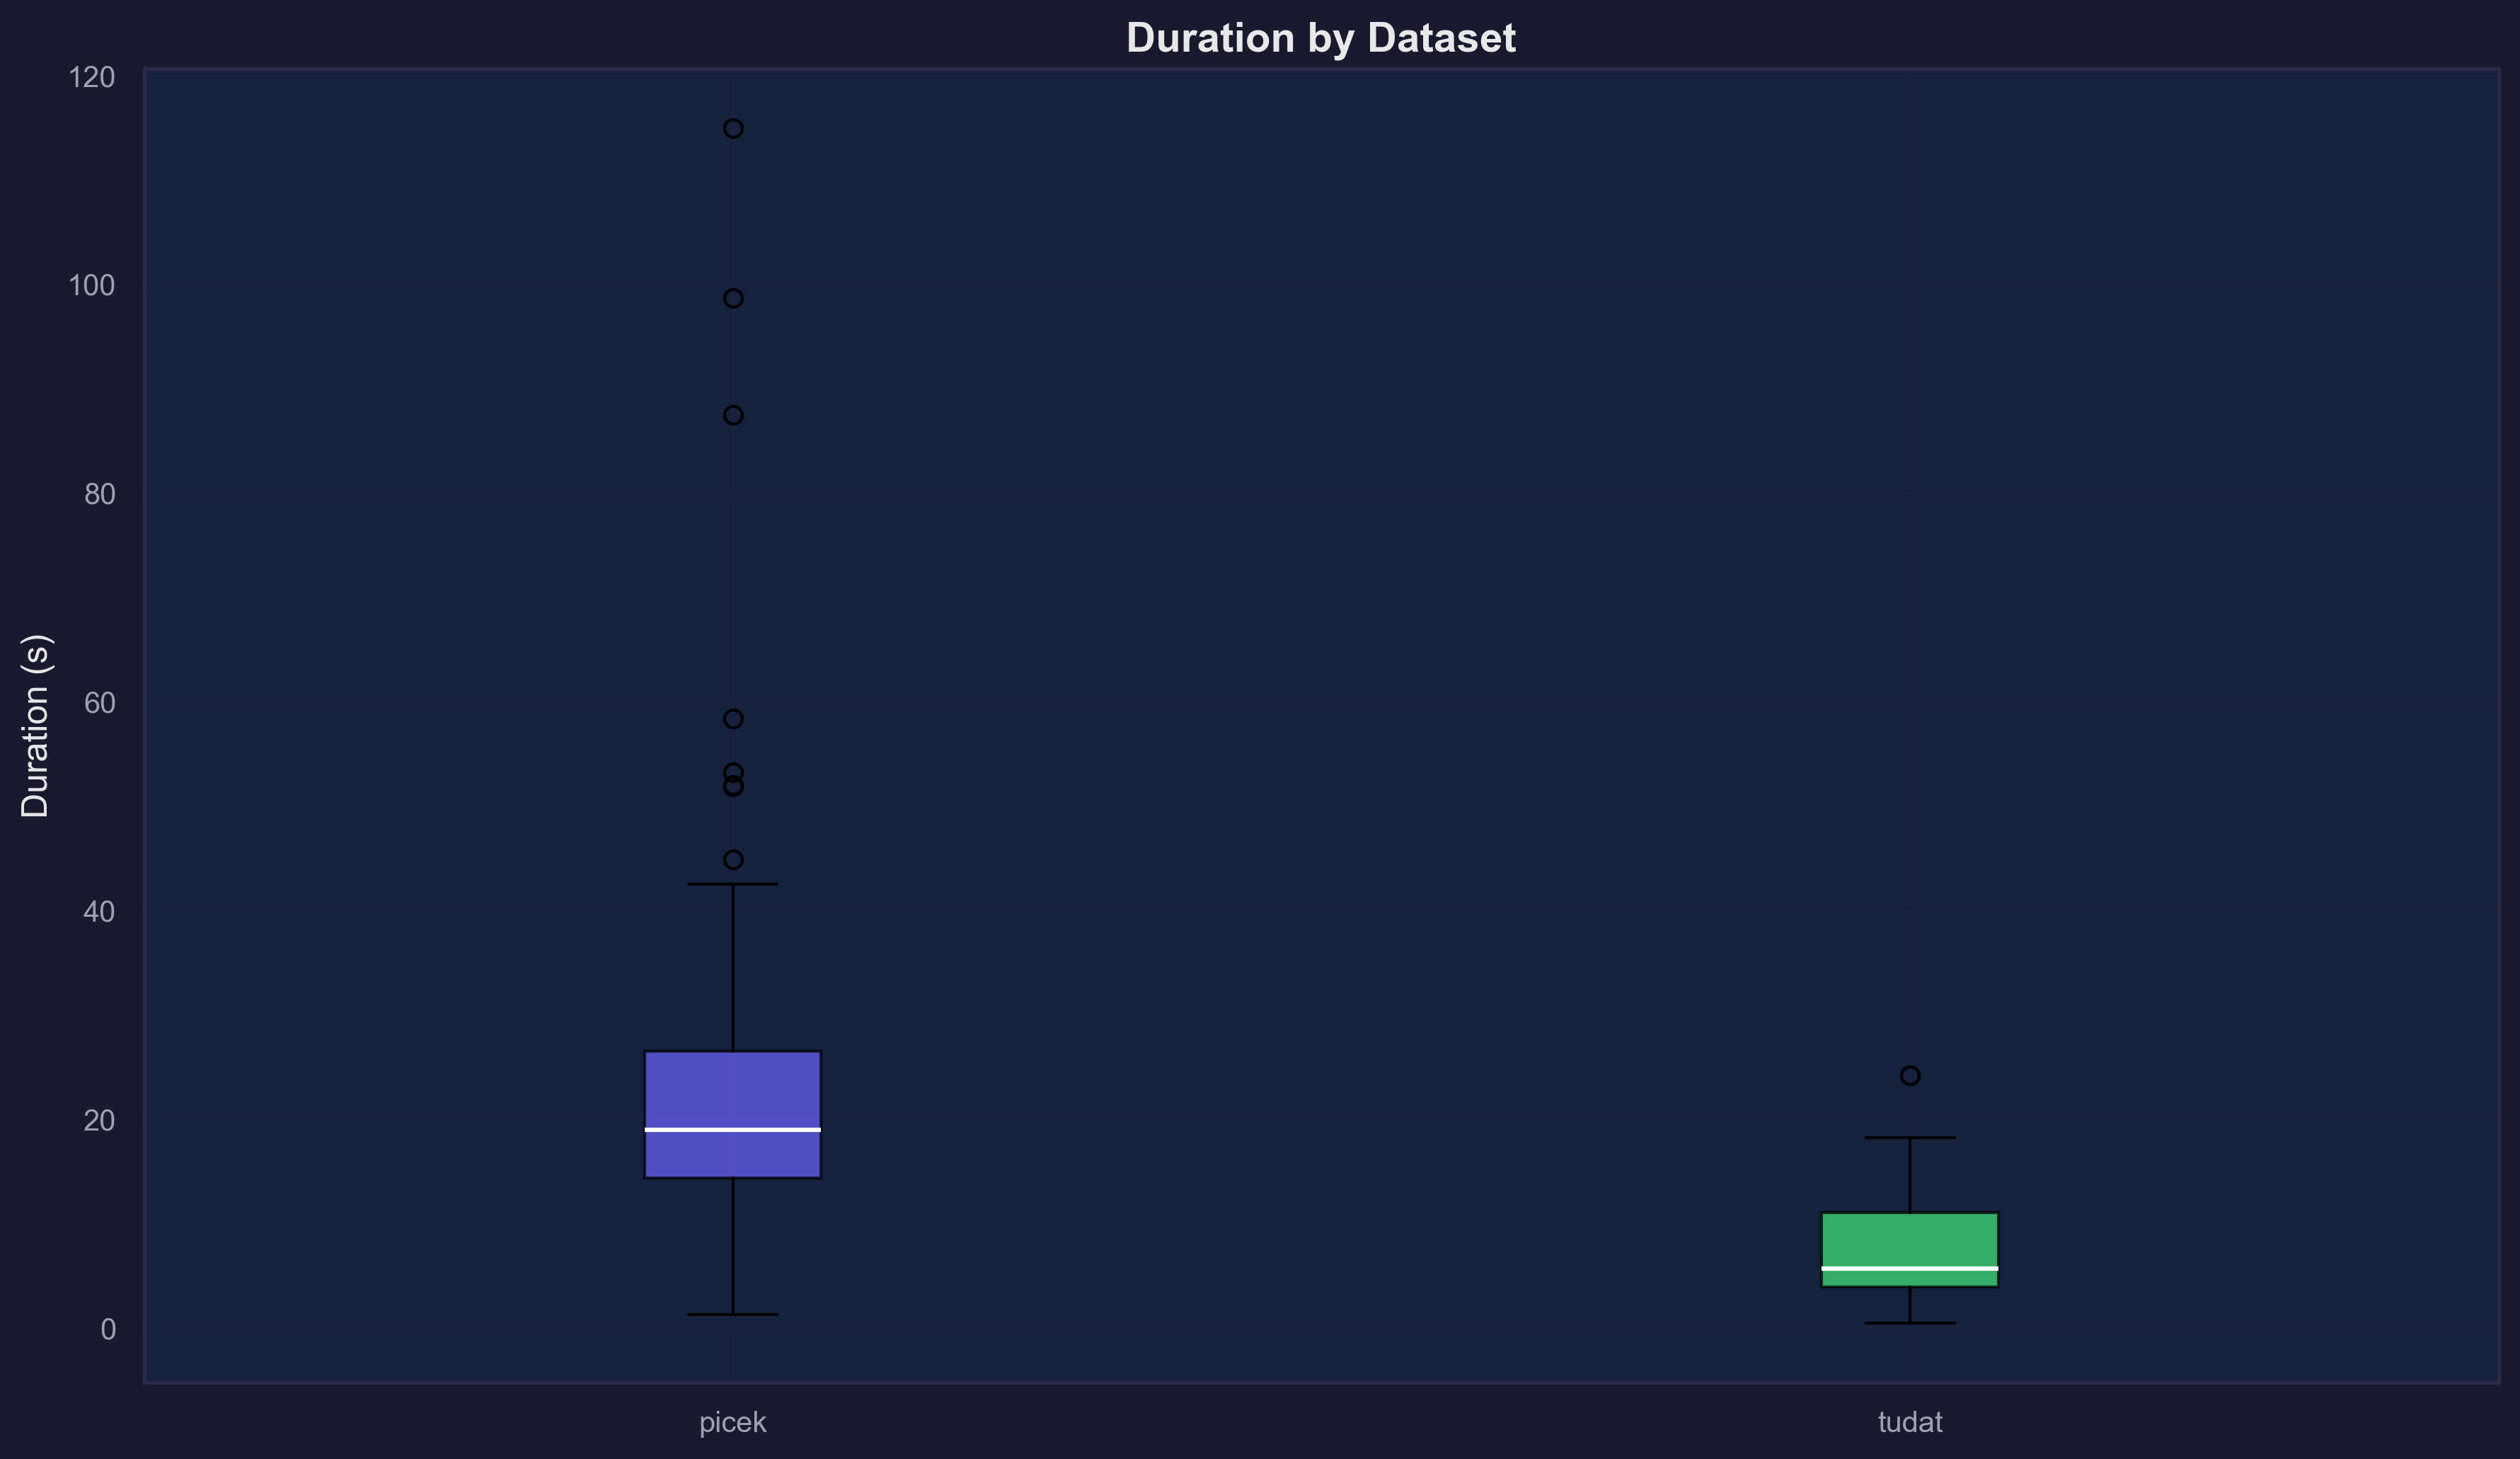

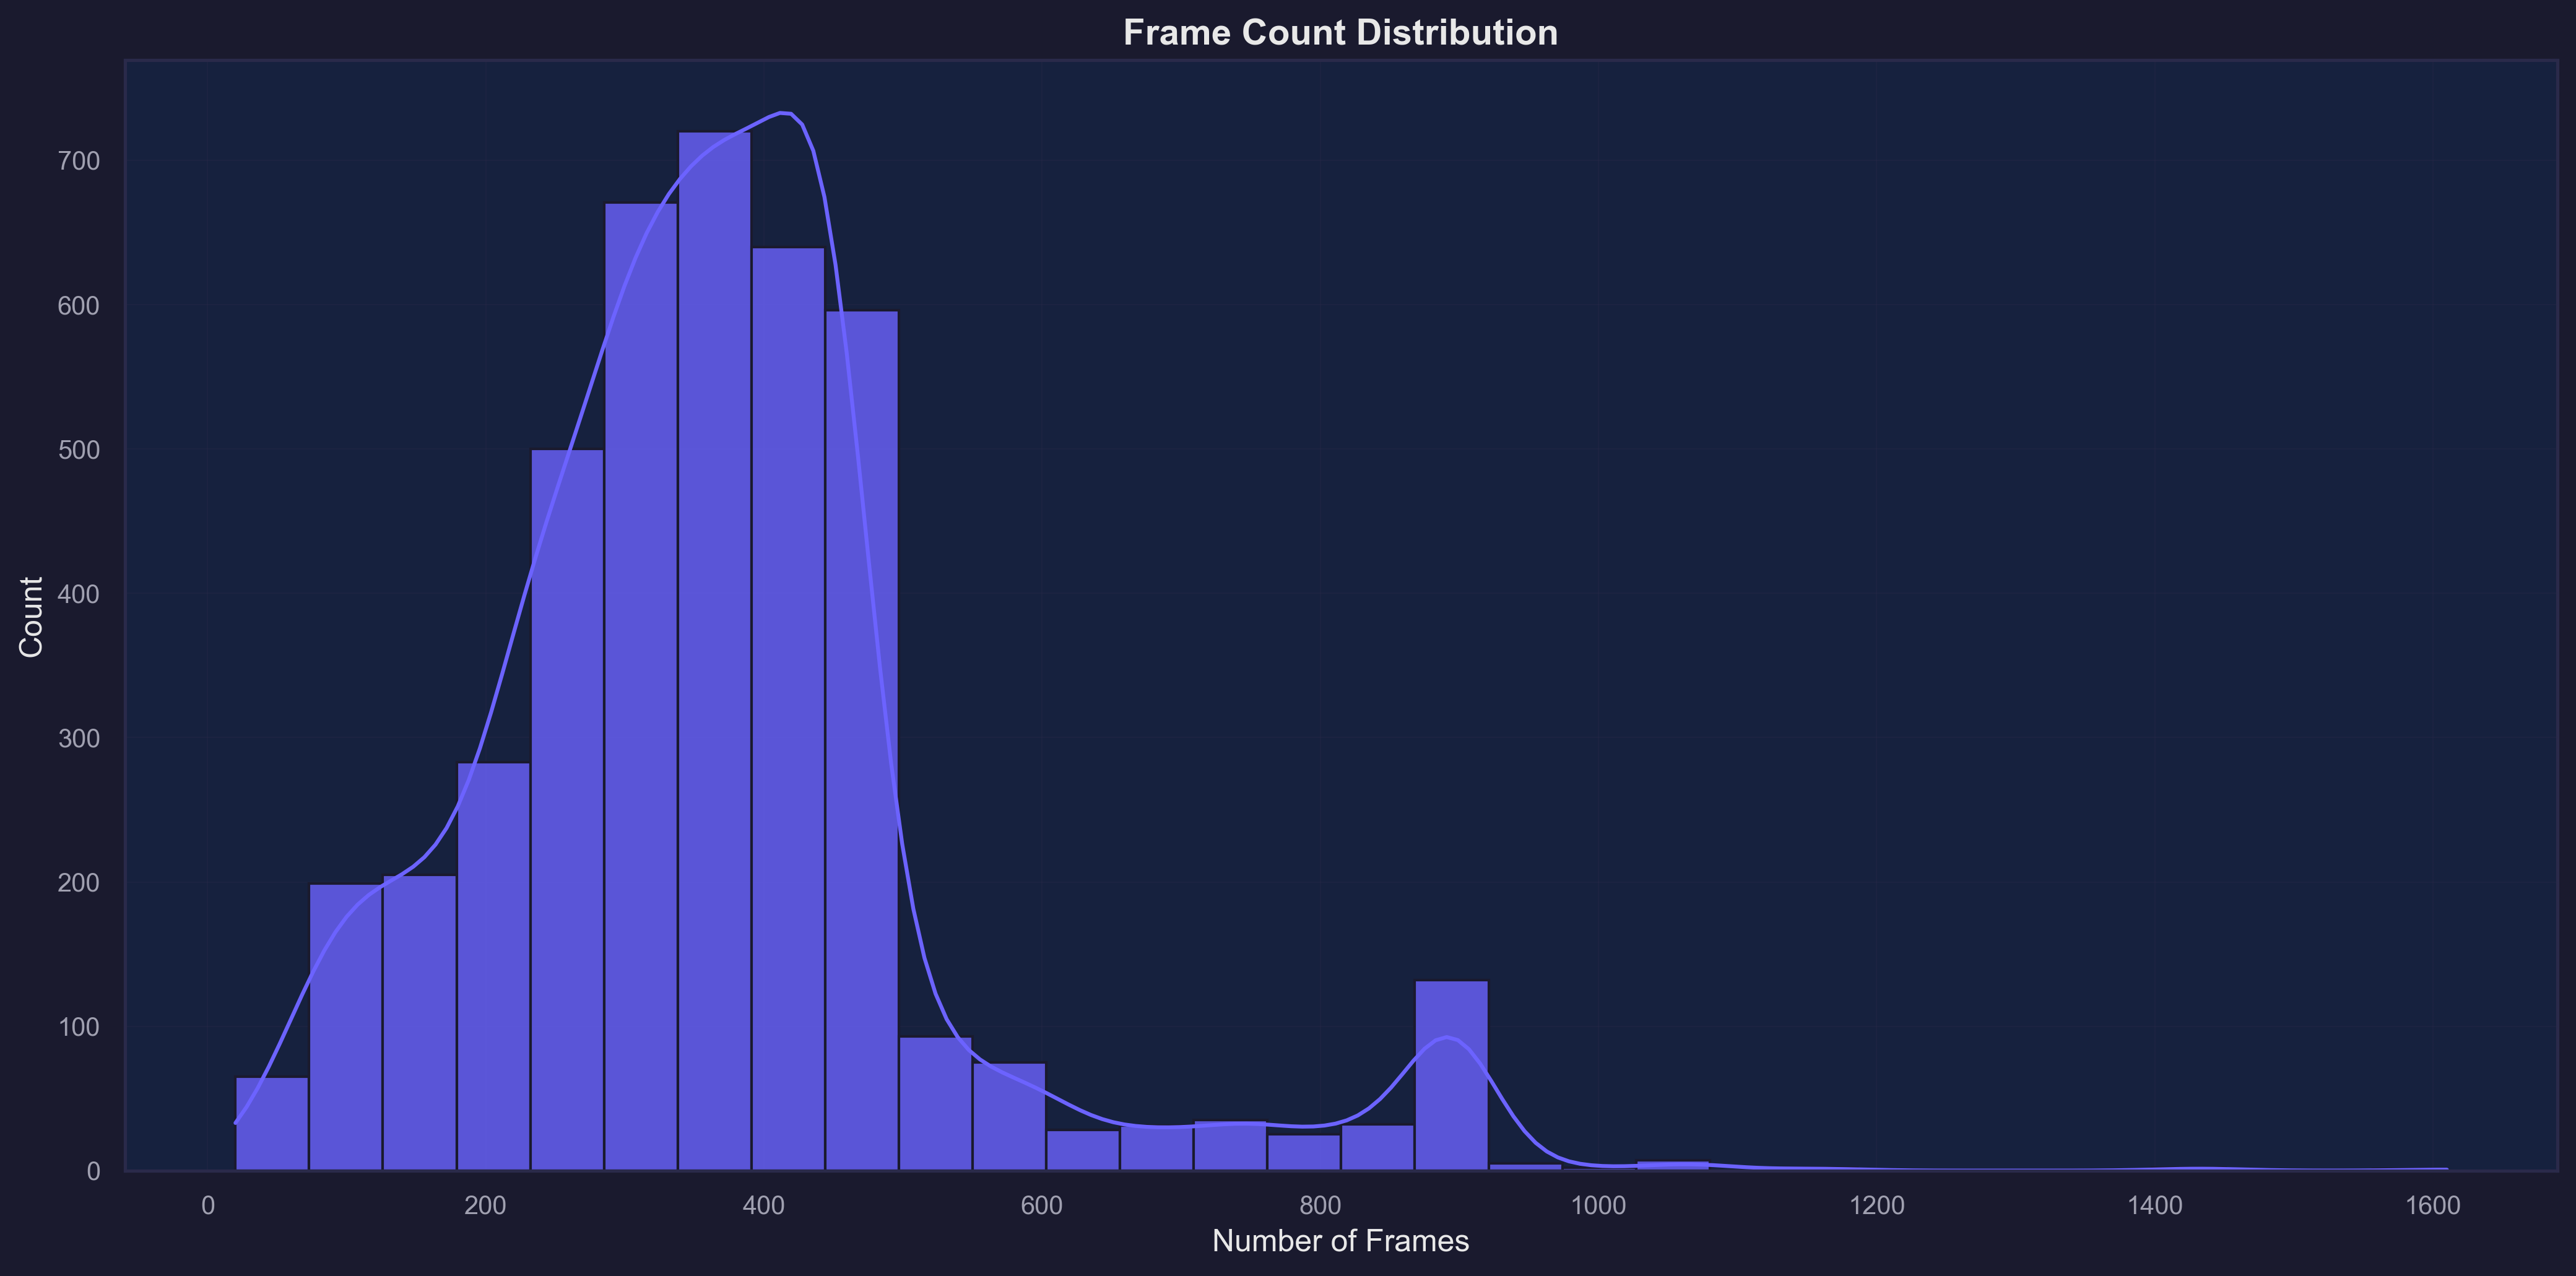

In [5]:
# Per-dataset duration box plots
datasets = analyzer.iter_datasets()
if dur.get("available") and len(datasets) > 1 and "duration" in df.columns:
    fig, ax = plot_engine.create_figure(figsize=(12, 7))
    plot_data = []
    labels = []
    for ds in datasets:
        ds_dur = df[df["dataset_name"] == ds]["duration"].dropna()
        if not ds_dur.empty:
            plot_data.append(ds_dur.values)
            labels.append(ds)
    if plot_data:
        bp = plot_engine.safe_boxplot(
            ax, plot_data, labels=labels, patch_artist=True,
            medianprops={"color": "white", "linewidth": 1.5},
        )
        if bp:
            for patch, ds in zip(bp["boxes"], labels):
                patch.set_facecolor(DATASET_COLOURS.get(ds, "#6C63FF"))
                patch.set_alpha(0.7)
        ax.set_title("Duration by Dataset", fontweight="bold")
        ax.set_ylabel("Duration (s)")
        plt.tight_layout()
        output.save_figure(fig, "duration_per_dataset")
        wb.log_figure(fig, "duration_per_dataset")
        plt.show()

# Frame count distribution
fc = results["frame_count"]
if fc.get("available") and fc.get("count", 0) > 0:
    fig, ax = plot_engine.create_figure(figsize=(14, 7))
    plot_engine.plot_distribution(
        df["no_frames"].dropna(),
        title="Frame Count Distribution",
        xlabel="Number of Frames",
        ax=ax,
    )
    plt.tight_layout()
    output.save_figure(fig, "frame_count_distribution")
    wb.log_figure(fig, "frame_count_distribution")
    plt.show()

## Report & Export

In [6]:
rg = ReportGenerator(
    NOTEBOOK_NAME,
    eda_version=config.eda_version,
    dataset_version=loader.dataset_version,
    metadata_hash=metadata_hash,
    git_commit=git_commit,
    seed=config.seed,
)

# Duration section
rg.add_heading("Duration Statistics")
if dur.get("available") and dur.get("count", 0) > 0:
    rg.add_key_value_list(dur["stats"])

# FPS section
rg.add_heading("FPS Statistics")
if fps.get("available") and fps.get("count", 0) > 0:
    rg.add_key_value_list(fps["stats"])

# Resolution section
rg.add_heading("Resolution Statistics")
if res.get("available") and res.get("count", 0) > 0:
    rg.add_key_value_list(res["height_stats"])
    # Build resolution CSV
    res_rows = [
        {"resolution": k, "count": v}
        for k, v in res.get("common_resolutions", {}).items()
    ]
    if res_rows:
        res_df = pd.DataFrame(res_rows).sort_values("count", ascending=False)
        rg.add_table(res_df, key="common_resolutions")
        output.save_csv(res_df, "resolution_distribution")

# Outliers section
rg.add_heading("Outlier Detection")
if outliers:
    out_rows = [
        {"column": col, "outlier_count": info["count"], "percent": info["percentage"]}
        for col, info in outliers.items()
    ]
    out_df = pd.DataFrame(out_rows)
    rg.add_table(out_df, key="outliers")

# Aggregate stats for summary JSON
rg.add_stats({
    "duration_count": dur.get("count", 0),
    "fps_count": fps.get("count", 0),
    "resolution_count": res.get("count", 0),
    "image_subset_count": img.get("count", 0),
    "outlier_columns": list(outliers.keys()) if outliers else [],
})

# Build a video stats summary CSV
summary_rows = []
for metric, key in [("duration", "duration"), ("fps", "fps"), ("frame_count", "frame_count")]:
    info = results.get(key, {})
    if info.get("available") and info.get("count", 0) > 0:
        row = {"metric": metric, "count": info["count"]}
        row.update(info["stats"])
        summary_rows.append(row)
if summary_rows:
    output.save_csv(pd.DataFrame(summary_rows), "video_stats_summary")

# Save reports
output.save_report(rg.build_markdown(), "video_statistics_report")
output.save_summary_json(rg.build_summary_json(), "summary")

# W&B logging
wb.log_stats({
    "video/duration_count": dur.get("count", 0),
    "video/fps_count": fps.get("count", 0),
    "video/resolution_count": res.get("count", 0),
    "video/image_subset_count": img.get("count", 0),
})

print("Reports and exports saved.")

Reports and exports saved.


## Teardown

In [7]:
snap_end = monitor.snapshot("end")
duration = time.time() - START_TIME

wb.log_system_info(snap_end)
wb.log_stats({"execution/duration_seconds": round(duration, 2)})
wb.log_notebook_outputs(
    output.figures_dir, output.reports_dir, output.exports_dir,
    metadata={"notebook": NOTEBOOK_NAME, "duration": round(duration, 2)},
)

output.finalize(
    wandb_run_id=wb.run_id, wandb_run_url=wb.run_url,
    git_commit=git_commit, metadata_hash=metadata_hash,
    rows_analyzed=df.shape[0], duration_seconds=duration,
)
logger.log_execution_summary(
    duration_seconds=duration, files_exported=output.all_exported_files,
    wandb_run_id=wb.run_id, wandb_run_url=wb.run_url,
)
wb.finish()

print(f"\n✅ Notebook complete in {duration:.1f}s")
print(f"   Exported {len(output.all_exported_files)} files")

wandb: Adding directory to artifact (E:\Rads\eda\figures\2026-08-01_16-42)... 

Done. 0.1s


wandb: Adding directory to artifact (E:\Rads\eda\reports\2026-08-01_16-42)... 

Done. 0.0s


wandb: Adding directory to artifact (E:\Rads\eda\exports\2026-08-01_16-42)... 

...

wandb: uploading data


wandb: 
wandb: Run history:
wandb: execution/duration_seconds ▁
wandb:           system/cpu/cores ▁▁
wandb:         system/cpu/percent ▁█
wandb:        system/disk/percent ▁▁
wandb:        system/disk/used_gb ▁▁
wandb:      system/memory/percent █▁
wandb:     system/memory/total_gb ▁▁
wandb:      system/memory/used_gb █▁
wandb:       video/duration_count ▁
wandb:            video/fps_count ▁
wandb:                         +2 ...
wandb: 
wandb: Run summary:
wandb: execution/duration_seconds 21.48
wandb:           system/cpu/cores 4
wandb:         system/cpu/percent 42.3
wandb:        system/disk/percent 68.7
wandb:        system/disk/used_gb 151.99
wandb:      system/memory/percent 90.5
wandb:     system/memory/total_gb 7.74
wandb:      system/memory/used_gb 7.01
wandb:       video/duration_count 4349
wandb:            video/fps_count 4349
wandb:                         +2 ...
wandb: 


wandb:  View run eda-03_video_statistics at: https://wandb.ai/saksham4data-vinkura/RADS/runs/ifnajcp0
wandb:  View project at: https://wandb.ai/saksham4data-vinkura/RADS
wandb: Synced 5 W&B file(s), 5 media file(s), 13 artifact file(s) and 0 other file(s)


wandb: Find logs at: .\wandb\run-20260801_221218-ifnajcp0\logs



✅ Notebook complete in 21.5s
   Exported 14 files
